In [341]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [342]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [343]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [344]:
df.shape

(344, 7)

There is 344 rows and 7 columns in the penguins dataset

In [345]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

# Columns Description

Species: Denotes penguin species(Adelie, Chinstrap, Gento)

Island: Isalndas penguine found

Bill_length: Bill length of penguines (mm)

Bill_depth : Bill depth of penguines (mm)

flipper_length: flipper length of penguines (mm)

body_mass_g: It the weight of the penguin measured in grams (g).

Sex: male, female


# Target column is species

# Data Analysis 

In [346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [347]:
df.duplicated().sum()

np.int64(0)

In [348]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [349]:
df['species'].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [350]:
df['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

There is three category in island.

Where Biscoe has the most penguine(168) and Torgersen has the lowest 52

In [351]:
df.groupby('species')['sex'].value_counts()

species    sex   
Adelie     Female    73
           Male      73
Chinstrap  Female    34
           Male      34
Gentoo     Male      61
           Female    58
Name: count, dtype: int64

Every species has almost equal amount of male and female

In [352]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

In [353]:
df.groupby('species')['island'].value_counts()

species    island   
Adelie     Dream         56
           Torgersen     52
           Biscoe        44
Chinstrap  Dream         68
Gentoo     Biscoe       124
Name: count, dtype: int64

Adelie species is found in every island. But Chinstrap are found only in Dream island. Gentoo found in only Biscoe islan

In [354]:
df.duplicated().sum()

np.int64(0)

No duplicate row in the dataset

# Handling the nan values

In [355]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

biil_length, bill_depth, flipper_length and body_mass , all have 2 nan values and sex column has 11 nan values.

In [356]:
df['bill_length_mm'] = df['bill_length_mm'].fillna(df['bill_length_mm'].mean())

In [357]:
mean_depth = df['bill_depth_mm'].mean()

df['bill_depth_mm'] = df['bill_depth_mm'].fillna(mean_depth)

In [358]:
mean_flipper = df['flipper_length_mm'].mean()

df['flipper_length_mm'] = df['flipper_length_mm'].fillna(mean_flipper)

In [359]:
mean_mass = df['body_mass_g'].mean()

df['body_mass_g'] = df['body_mass_g'].fillna(mean_mass)

In [360]:
df['sex'].value_counts()

sex
Male      168
Female    165
Name: count, dtype: int64

In [361]:
mode_sex = df['sex'].mode()[0]

df['sex'] = df['sex'].fillna(mode_sex)

In [362]:
df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [363]:
df.shape

(344, 7)

# Outliers handling

<Axes: ylabel='bill_length_mm'>

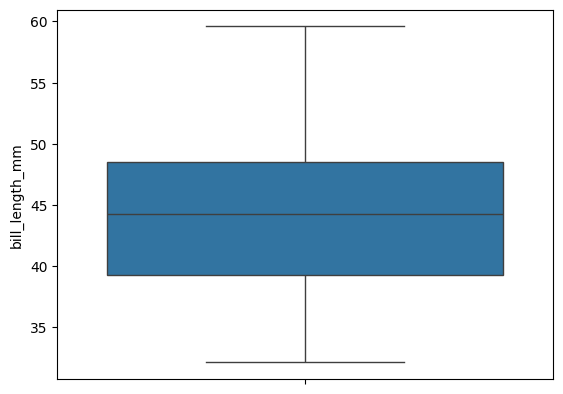

In [364]:
sns.boxplot(df['bill_length_mm'])

<Axes: ylabel='bill_depth_mm'>

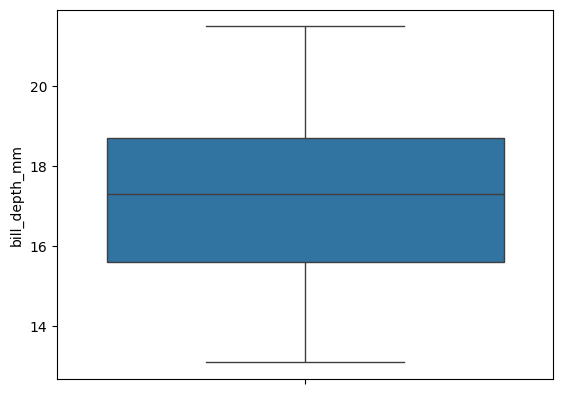

In [365]:
sns.boxplot(df['bill_depth_mm'])

<Axes: ylabel='flipper_length_mm'>

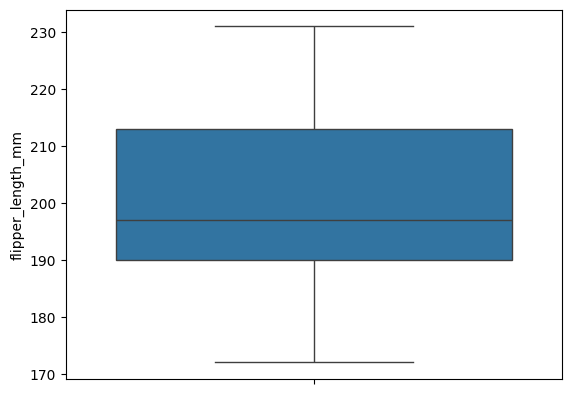

In [366]:
sns.boxplot(df['flipper_length_mm'])

<Axes: ylabel='body_mass_g'>

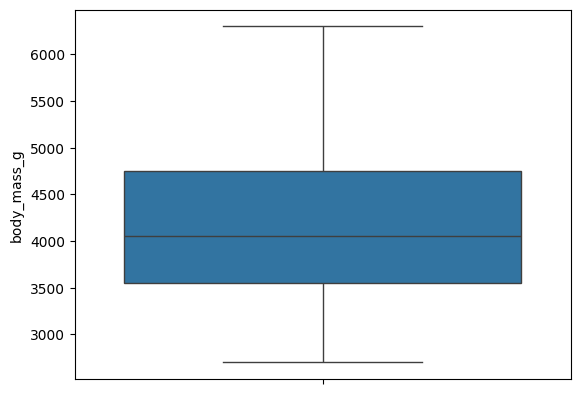

In [367]:
sns.boxplot(df['body_mass_g'])

There is no outliers in the dataset.

In [368]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()
df4 = df.copy()

# Encoding

In [369]:
# Encoding using replace

from pandas.api.types import is_numeric_dtype

In [370]:
for col in df1.columns:
    uniq = df1[col].unique().tolist()
    count = df1[col].nunique()

    if count == 2:
        df1[col] = df1[col].replace(uniq, [0,1])

    if count == 3:
        df1[col] = df1[col].replace(uniq, [0,1,2])

    if count == 4:
        df1[col] = df1[col].replace(uniq, [0,1,2,3])

C:\Users\bikra\AppData\Local\Temp\ipykernel_5612\2951150709.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col] = df1[col].replace(uniq, [0,1,2])
C:\Users\bikra\AppData\Local\Temp\ipykernel_5612\2951150709.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1[col] = df1[col].replace(uniq, [0,1])


In [371]:
df1.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,0,39.10000,18.70000,181.000000,3750.000000,0
1,0,0,39.50000,17.40000,186.000000,3800.000000,1
2,0,0,40.30000,18.00000,195.000000,3250.000000,1
3,0,0,43.92193,17.15117,200.915205,4201.754386,0
4,0,0,36.70000,19.30000,193.000000,3450.000000,1


In [372]:
df1['species'].value_counts()

species
0    152
2    124
1     68
Name: count, dtype: int64

In [373]:
df1['island'].value_counts()

island
1    168
2    124
0     52
Name: count, dtype: int64

In [374]:
df5 = df.copy()
df6 = df.copy()
df7 = df.copy()
df8 = df.copy()

In [375]:
# Label Encoding 

le = LabelEncoder()

In [376]:
df3.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female


In [377]:
for col in df3.columns:
    if not is_numeric_dtype(df3[col]):
        df3[col] = le.fit_transform(df3[[col]])

df3.head()

c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\bikra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,2,39.10000,18.70000,181.000000,3750.000000,1
1,0,2,39.50000,17.40000,186.000000,3800.000000,0
2,0,2,40.30000,18.00000,195.000000,3250.000000,0
3,0,2,43.92193,17.15117,200.915205,4201.754386,1
4,0,2,36.70000,19.30000,193.000000,3450.000000,0


In [378]:
df3['species'].value_counts()

species
0    152
2    124
1     68
Name: count, dtype: int64

In [379]:
df3['island'].value_counts()

island
0    168
1    124
2     52
Name: count, dtype: int64

In [380]:
# Ordinal encoding

ord = OrdinalEncoder()

In [381]:
for col in df2.columns:
    if not is_numeric_dtype(df2[col]):
        df2[col] = ord.fit_transform(df2[[col]])

df2.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.0,2.0,39.10000,18.70000,181.000000,3750.000000,1.0
1,0.0,2.0,39.50000,17.40000,186.000000,3800.000000,0.0
2,0.0,2.0,40.30000,18.00000,195.000000,3250.000000,0.0
3,0.0,2.0,43.92193,17.15117,200.915205,4201.754386,1.0
4,0.0,2.0,36.70000,19.30000,193.000000,3450.000000,0.0


In [382]:
df2['island'].value_counts()

island
0.0    168
1.0    124
2.0     52
Name: count, dtype: int64

In [383]:
df2['species'].value_counts()

species
0.0    152
2.0    124
1.0     68
Name: count, dtype: int64

In [384]:
# One-hot encoding using dummy

ohe = OneHotEncoder(sparse_output= False)
df4.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female


In [385]:
dummy = pd.get_dummies(df4['species'], drop_first= True, prefix= 'species').astype('int')
dummy

,species_Chinstrap,species_Gentoo
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
339,0,1
340,0,1
341,0,1
342,0,1


In [386]:
df4 = df4.drop(['species'], axis = 1)

In [387]:
df4.columns

Index(['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm',
       'body_mass_g', 'sex'],
      dtype='object')

In [388]:
df4 = pd. concat([df4,dummy], axis = 1)

In [389]:
df4.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_Chinstrap,species_Gentoo
0,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male,0,0
1,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female,0,0
2,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female,0,0
3,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male,0,0
4,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female,0,0


In [390]:
# algorithm

df5['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

In [391]:
encode = ohe.fit(df5[['island']])

In [392]:
encode_data = encode.transform(df5[['island']])

In [393]:
encode_data

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]], shape=(344, 3))

In [394]:
data = pd.DataFrame(encode_data, columns = ohe.get_feature_names_out(['island']))

In [395]:
data

,island_Biscoe,island_Dream,island_Torgersen
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
...,...,...,...
339,1.0,0.0,0.0
340,1.0,0.0,0.0
341,1.0,0.0,0.0
342,1.0,0.0,0.0


In [396]:
df5 = df5.drop(['island'], axis = 1)

In [397]:
df5.head() # check the column dropped or not

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,36.70000,19.30000,193.000000,3450.000000,Female


In [398]:
df5 = pd.concat([df5,data], axis= 1)

In [399]:
df5.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Biscoe,island_Dream,island_Torgersen
0,Adelie,39.10000,18.70000,181.000000,3750.000000,Male,0.0,0.0,1.0
1,Adelie,39.50000,17.40000,186.000000,3800.000000,Female,0.0,0.0,1.0
2,Adelie,40.30000,18.00000,195.000000,3250.000000,Female,0.0,0.0,1.0
3,Adelie,43.92193,17.15117,200.915205,4201.754386,Male,0.0,0.0,1.0
4,Adelie,36.70000,19.30000,193.000000,3450.000000,Female,0.0,0.0,1.0


# we will use dummy for one-hot encoding . 
This is easy process

In [400]:
df6.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,Male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,Female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,Female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,Male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,Female


In [401]:
for col in df6.columns:
    if not is_numeric_dtype(df6[col]):
        dummy = pd.get_dummies(df6[col], drop_first= True, prefix= col).astype('Int64')
        df6 = df6.drop([col], axis= 1)
        df6 = pd.concat([df6, dummy], axis= 1)



In [402]:
df6.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,39.10000,18.70000,181.000000,3750.000000,0,0,0,1,1
1,39.50000,17.40000,186.000000,3800.000000,0,0,0,1,0
2,40.30000,18.00000,195.000000,3250.000000,0,0,0,1,0
3,43.92193,17.15117,200.915205,4201.754386,0,0,0,1,1
4,36.70000,19.30000,193.000000,3450.000000,0,0,0,1,0


# Scaling

We will use standard scaler for scaling. Becasue it works better in Linear/ Logistic regression.

In [403]:
scaler = StandardScaler()

In [404]:
df9 = df6.copy()

In [407]:
df6['bill_length_mm'] = scaler.fit_transform(df6[['bill_length_mm']])

In [409]:
df6['bill_length_mm'].min()

np.float64(-2.1748578638385965)

In [410]:
df6['bill_length_mm'].max()

np.float64(2.884264643495378)

In [415]:
df6['bill_length_mm'].std()

np.float64(1.0014566650110448)

In [416]:
df6['bill_length_mm'].mean()

np.float64(-1.1566974768187678e-15)

In [411]:
df6['bill_depth_mm'] = scaler.fit_transform(df6[['bill_depth_mm']])

In [412]:
df6['flipper_length_mm'] = scaler.fit_transform(df6[['flipper_length_mm']])

In [413]:
df6['body_mass_g'] = scaler.fit_transform(df6[['body_mass_g']])

In [414]:
df6.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,-8.870812e-01,7.877425e-01,-1.422488,-0.565789,0,0,0,1,1
1,-8.134940e-01,1.265563e-01,-1.065352,-0.503168,0,0,0,1,0
2,-6.663195e-01,4.317192e-01,-0.422507,-1.192003,0,0,0,1,0
3,-1.307172e-15,1.806927e-15,0.000000,0.000000,0,0,0,1,1
4,-1.328605e+00,1.092905e+00,-0.565361,-0.941517,0,0,0,1,0


In [405]:
df9.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_Male
0,39.10000,18.70000,181.000000,3750.000000,0,0,0,1,1
1,39.50000,17.40000,186.000000,3800.000000,0,0,0,1,0
2,40.30000,18.00000,195.000000,3250.000000,0,0,0,1,0
3,43.92193,17.15117,200.915205,4201.754386,0,0,0,1,1
4,36.70000,19.30000,193.000000,3450.000000,0,0,0,1,0
